---

# Dimensionality Reduction with t-SNE

t-SNE (t-distributed Stochastic Neighbor Embedding) is a nonlinear dimensionality reduction technique that is particularly well suited for visualizing high-dimensional data in 2D or 3D. Unlike PCA which preserves global variance, t-SNE focuses on preserving local structure — keeping similar points close together in the reduced space.

t-SNE works by:
1. Computing pairwise similarities between points in the high-dimensional space
2. Defining a similar probability distribution in the low-dimensional space
3. Minimizing the difference between the two distributions using gradient descent

In this notebook we apply t-SNE to the Breast Cancer Wisconsin dataset and compare its visualization to PCA to see which better separates the two classes.

---

In [13]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Our own TSNE implementation from ml_pack
from ml_pack import TSNE

# Sklearn PCA for comparison and preprocessing only
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

---

## Loading and Exploring the Data

---

In [14]:
# Load the Breast Cancer dataset
df = pd.read_csv("breast_cancer.csv")

# Check dimensions and preview
print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---

## Preprocessing

---

In [15]:
# Separate features and target
X = df.drop(columns='target').values
y = df['target'].values

# Standardize features before applying t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Class distribution:", dict(zip(*np.unique(y, return_counts=True))))

Feature matrix shape: (569, 30)
Class distribution: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}


---

## Applying t-SNE

We reduce the data to 2 dimensions using t-SNE. Note that t-SNE is slower than PCA and is not deterministic — results may vary between runs unless a random state is set.

---

In [16]:
# Apply our ml_pack t-SNE to reduce to 2 dimensions
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE output shape:", X_tsne.shape)

t-SNE output shape: (569, 2)


---

## Visualizing the t-SNE Embedding

---

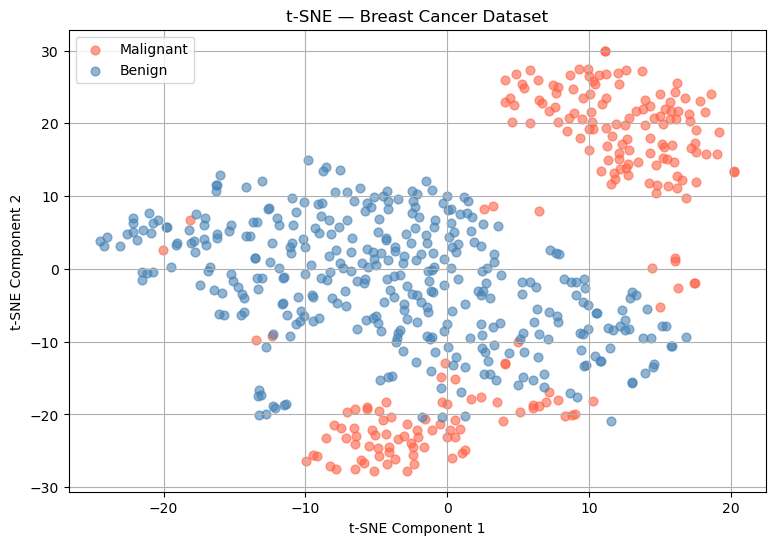

In [17]:
# Plot the t-SNE embedding
plt.figure(figsize=(9, 6))
for label, color, name in zip([0, 1], ['tomato', 'steelblue'], ['Malignant', 'Benign']):
    mask = y == label
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], color=color, s=40, alpha=0.6, label=name)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE — Breast Cancer Dataset")
plt.legend()
plt.grid(True)
plt.show()

---

## Comparing t-SNE and PCA

Let's plot both t-SNE and PCA side by side to see which better separates the two classes.

---

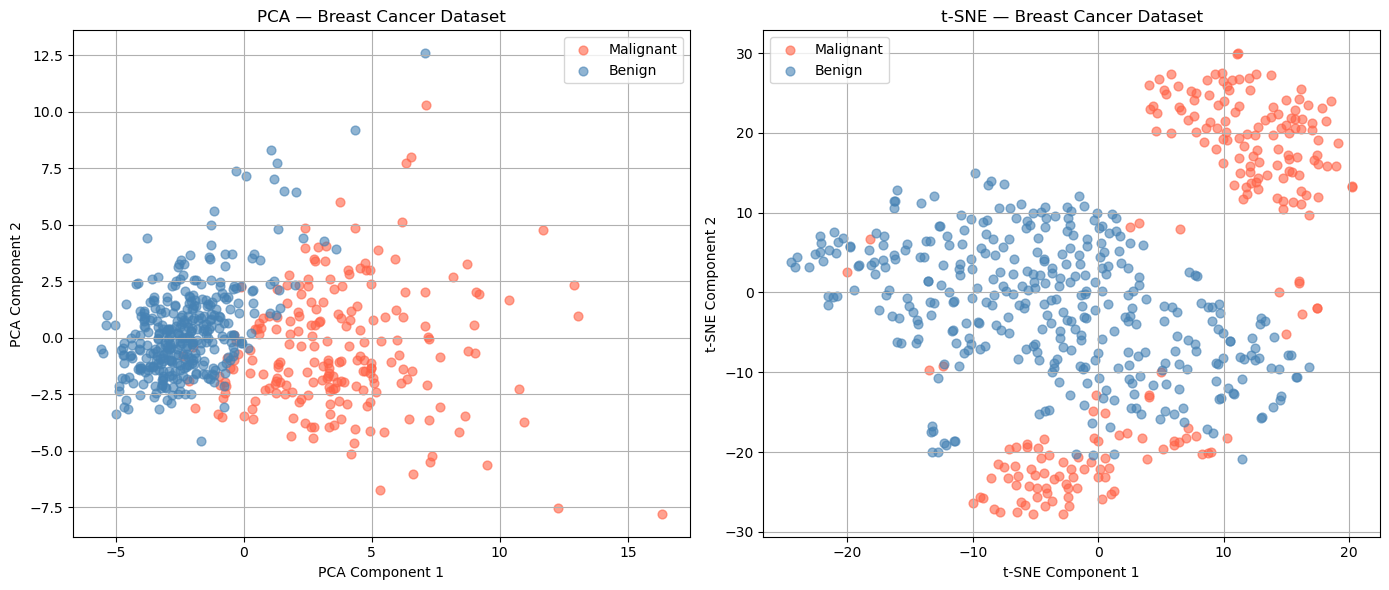

In [18]:
# Apply PCA for comparison
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, X_reduced, title in zip(axes,
                                  [X_pca, X_tsne],
                                  ['PCA', 't-SNE']):
    for label, color, name in zip([0, 1], ['tomato', 'steelblue'], ['Malignant', 'Benign']):
        mask = y == label
        ax.scatter(X_reduced[mask, 0], X_reduced[mask, 1], color=color, s=40, alpha=0.6, label=name)
    ax.set_title(f"{title} — Breast Cancer Dataset")
    ax.set_xlabel(f"{title} Component 1")
    ax.set_ylabel(f"{title} Component 2")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

---

## Summary

In this notebook we applied t-SNE to visualize the Breast Cancer Wisconsin dataset in 2D and compared it to PCA. 

Key takeaways:
- t-SNE produces tighter, more clearly separated clusters than PCA for this dataset
- PCA is a linear method that preserves global variance — it works well but the classes overlap more in 2D
- t-SNE is a nonlinear method that preserves local structure — similar points stay close together, producing cleaner cluster separation
- t-SNE is slower than PCA and not suitable for dimensionality reduction before model training since it cannot transform new data points
- PCA is preferred when you need a reusable transformation; t-SNE is preferred for visualization

---